# El Amazonas que enfría: 6.8 W/m² de paradoja

> Pierdes un kilómetro cuadrado de Amazonas y el techo de la atmósfera —medido por satélite— deja escapar **más** energía hacia el espacio. ¿Eso significa que deforestar enfría el planeta?

**Paper:** Dror et al. (2026), *Amazon forest loss: An all-sky biophysical top-of-atmosphere cooling feedback*, **Science**.

**DOI:** [10.1126/science.adz8296](https://doi.org/10.1126/science.adz8296)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-23-amazon-forest-cooling-feedback/notebook.ipynb)

**Video del canal:** [Pendiente]


## Qué medimos y por qué importa

Tenemos dos décadas de satélites (CERES y MODIS) mirando el Amazonas y midiendo dos cosas a la vez:

1. **Cuánta energía radiativa sale por el techo de la atmósfera** (TOA, *top of atmosphere*) — separada en onda corta (luz solar reflejada, SW) y onda larga (calor infrarrojo emitido, LW).
2. **Qué fracción del bosque se ha perdido** en cada celda de 0.25° × 0.25° (≈ 27 km), agrupada en bins de fracción de pérdida `f_loss` entre 0 (intacto) y 0.85 (casi completamente deforestado).

Si la pérdida de bosque cambia el albedo (qué tan brillante se ve la superficie) o las nubes, el TOA debería cambiar también. Veamos qué encontraron.


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
THRESHOLD_HIGH_LOSS = 0.5     # Umbral de "alta deforestación" (fracción)
HEADLINE_VALUE = 6.8          # Valor headline del paper (W/m²) en f_loss≥0.5
HEADLINE_2SE = 0.6            # Incertidumbre 2σ del headline (W/m²)
COLOR_DATOS = '#2563EB'       # Azul CaM — datos principales
COLOR_ALERTA = '#DC2626'      # Rojo — referencia / alerta
COLOR_REFERENCIA = '#D97706'  # Amber — surface-only / pre-industrial
COLOR_LW = '#059669'          # Emerald — onda larga
FUENTE = 'Fuente: Dror et al. (2026), Science | Datos: NOAA Chemical Sciences Laboratory'

# Imports
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM (local primero, GitHub raw como fallback)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file,
        )
plt.style.use(style_file)

# Carga de datos (122 bins de f_loss con flujos TOA pre-calculados)
df = pd.read_csv('datos/toa_flux_vs_forest_loss.csv')
summary = pd.read_csv('datos/feedback_summary.csv')

print(f"Bins de f_loss cargados: {len(df)}")
print(f"Rango de f_loss: {df['f_loss'].min():.2f} – {df['f_loss'].max():.2f}")
print(f"Rango de ΔF_SW: {df['dF_SW_Wm2'].min():.2f} – {df['dF_SW_Wm2'].max():.2f} W/m²")
print(f"Rango de ΔF_LW: {df['dF_LW_Wm2'].min():.2f} – {df['dF_LW_Wm2'].max():.2f} W/m²")


Bins de f_loss cargados: 122
Rango de f_loss: 0.05 – 0.85
Rango de ΔF_SW: -2.84 – 11.56 W/m²
Rango de ΔF_LW: -0.55 – 1.24 W/m²


## Aquí está.

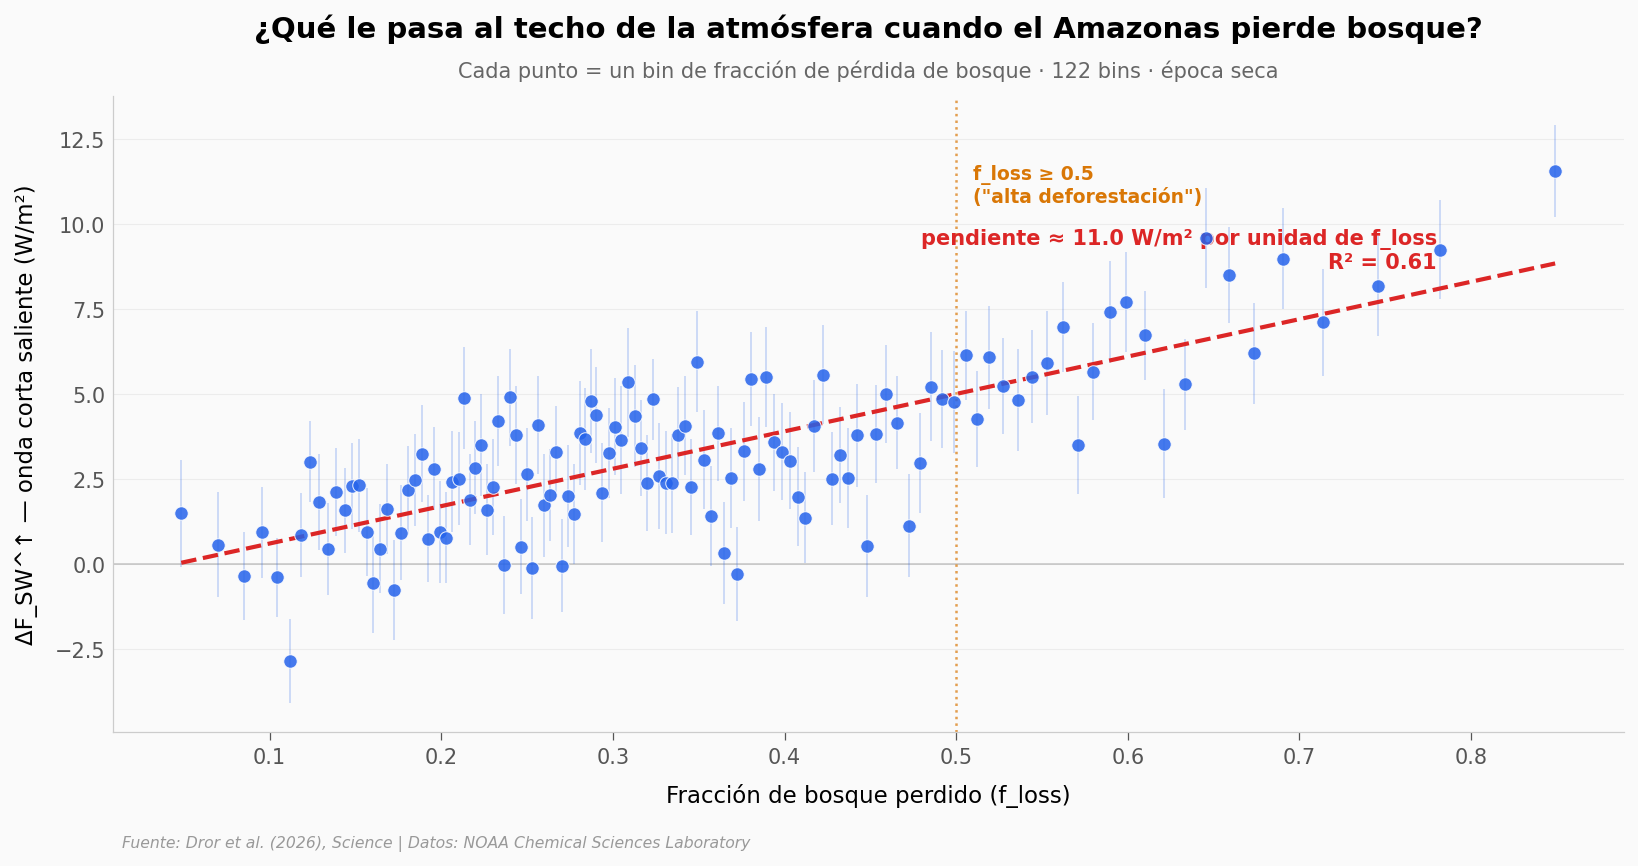


Pendiente OLS: 11.00 W/m² por unidad de f_loss
Pearson r: 0.780 | R²: 0.608 | p: 3.70e-26


In [2]:
# Regresión OLS: ΔF_SW vs f_loss
slope, intercept, r_value, p_value, std_err = stats.linregress(df['f_loss'], df['dF_SW_Wm2'])
x_fit = np.linspace(df['f_loss'].min(), df['f_loss'].max(), 100)
y_fit = slope * x_fit + intercept

fig, ax = plt.subplots(figsize=(13, 5.5))

# Scatter de los 122 bins, tamaño constante, error en SE como barra fina
ax.errorbar(df['f_loss'], df['dF_SW_Wm2'], yerr=df['dF_SW_SE_Wm2'],
            fmt='none', ecolor=COLOR_DATOS, alpha=0.25, elinewidth=0.8, zorder=3)
ax.scatter(df['f_loss'], df['dF_SW_Wm2'], color=COLOR_DATOS, s=42, alpha=0.85,
           edgecolors='white', linewidths=0.5, zorder=5)

# Línea de regresión
ax.plot(x_fit, y_fit, color=COLOR_ALERTA, linewidth=2, linestyle='--', zorder=4)
ax.text(0.78, slope * 0.78 + intercept + 0.6,
        f'pendiente ≈ {slope:.1f} W/m² por unidad de f_loss\nR² = {r_value**2:.2f}',
        fontsize=10, color=COLOR_ALERTA, fontweight='bold', ha='right')

# Línea horizontal en cero
ax.axhline(y=0, color='#999999', linewidth=0.8, linestyle='-', alpha=0.5)

# Marca el umbral de "alta deforestación"
ax.axvline(x=THRESHOLD_HIGH_LOSS, color=COLOR_REFERENCIA, linewidth=1.2, linestyle=':', alpha=0.7)
ax.text(THRESHOLD_HIGH_LOSS + 0.01, df['dF_SW_Wm2'].max() * 0.92,
        f'f_loss ≥ {THRESHOLD_HIGH_LOSS}\n("alta deforestación")',
        fontsize=9, color=COLOR_REFERENCIA, fontweight='bold')

ax.set_title('¿Qué le pasa al techo de la atmósfera cuando el Amazonas pierde bosque?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto = un bin de fracción de pérdida de bosque · 122 bins · época seca',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xlabel('Fracción de bosque perdido (f_loss)', fontsize=11)
ax.set_ylabel('ΔF_SW^↑ — onda corta saliente (W/m²)', fontsize=11)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/sw_vs_floss.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nPendiente OLS: {slope:.2f} W/m² por unidad de f_loss")
print(f"Pearson r: {r_value:.3f} | R²: {r_value**2:.3f} | p: {p_value:.2e}")


La nube de puntos sube. La señal aparece despacio: en bins con poca pérdida (f_loss < 0.2) los puntos se reparten alrededor de cero — el ruido satelital domina. Pero a partir de ahí la pendiente se vuelve evidente: cada unidad de fracción perdida añade unos **11 W/m²** al flujo saliente. Un píxel hipotéticamente deforestado al 100% se vería desde el espacio enviando ~11 W/m² más al espacio que un píxel intacto.

Eso suena a "deforestar enfría". Pero hay una pregunta antes de aceptar esa lectura: **¿cuánto de ese efecto viene del suelo —pasto reflejando más que árboles— y cuánto viene de las nubes que se forman encima?**


## Quitemos las nubes

Comparemos dos escenarios:

- **All-sky:** lo que el satélite ve realmente — superficie + nubes mezcladas.
- **Surface-only:** un cálculo que descuenta el efecto nuboso y deja solo el cambio de albedo del suelo.

Si las nubes no importaran, ambos números serían iguales. Si importan, deberían diverger.


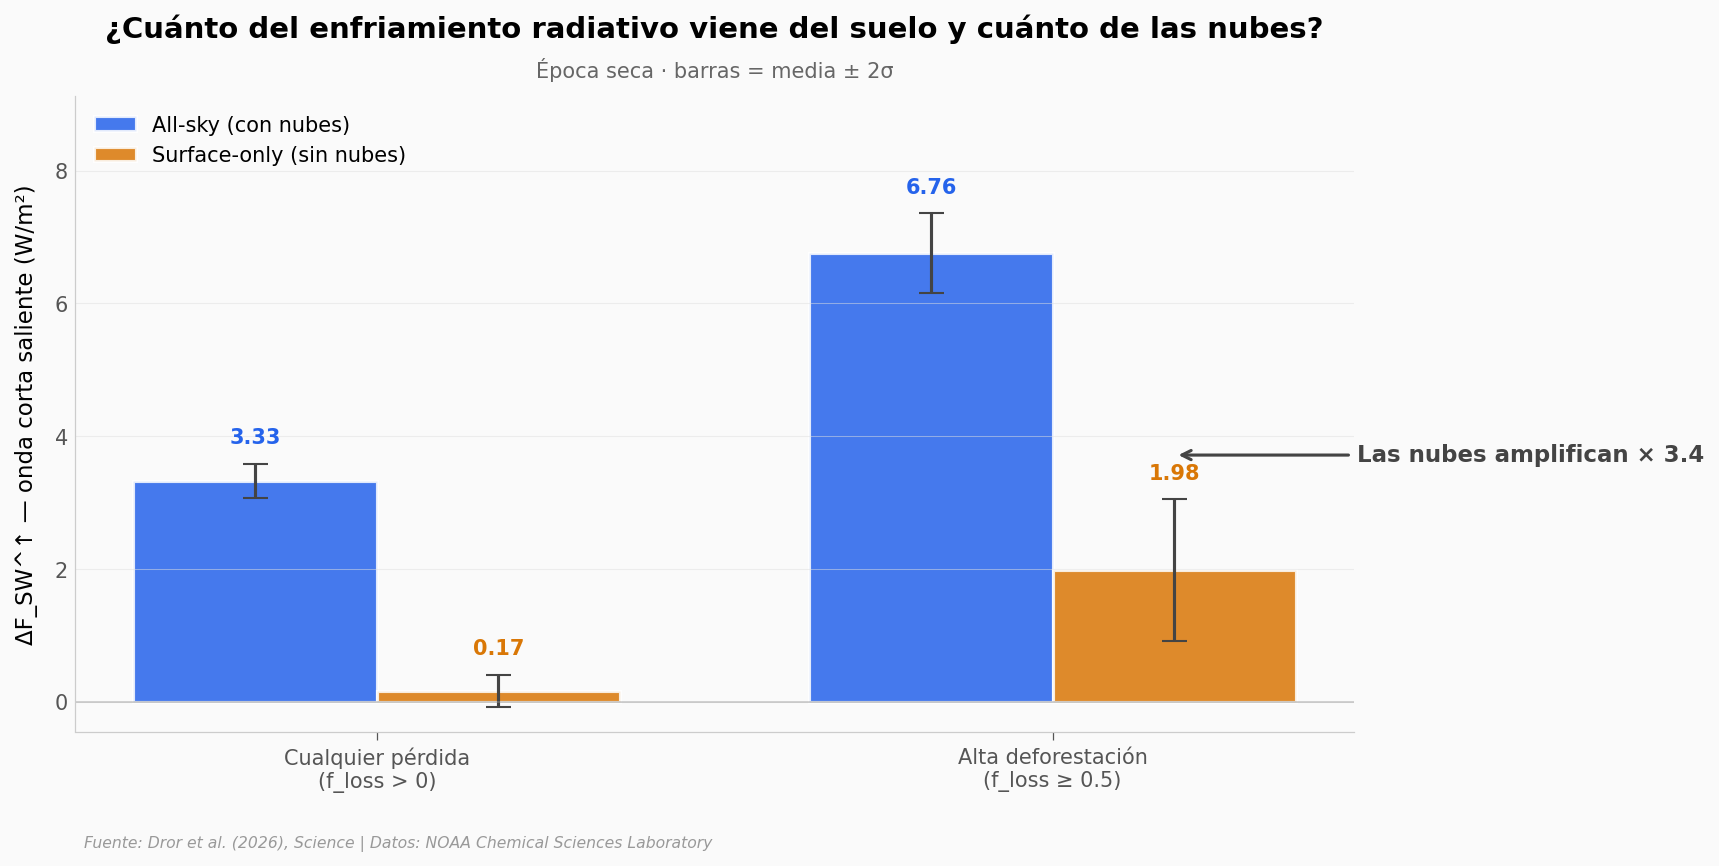


En alta deforestación (f_loss ≥ 0.5):
  All-sky:      6.76 W/m² ← lo que el satélite ve
  Surface-only:  1.98 W/m² ← solo cambio de albedo del suelo
  Amplificación de nubes: × 3.41


In [3]:
# Filtrar el summary: estación seca, ΔF_SW, ambos umbrales
sub = summary[(summary['season']=='dry') & (summary['quantity']=='Fsw')].copy()

groups = ['f_loss_gt_0', 'f_loss_geq_0.5']
group_labels = ['Cualquier pérdida\n(f_loss > 0)', 'Alta deforestación\n(f_loss ≥ 0.5)']
skies = ['all_sky', 'surface_only']
sky_labels = ['All-sky (con nubes)', 'Surface-only (sin nubes)']
colors = [COLOR_DATOS, COLOR_REFERENCIA]

x_positions = np.arange(len(groups))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(11, 5.5))

for i, (sky, color, label) in enumerate(zip(skies, colors, sky_labels)):
    means = []
    errs = []
    for g in groups:
        row = sub[(sub['sky']==sky) & (sub['threshold']==g)].iloc[0]
        means.append(row['mean'])
        errs.append(row['standard_error_2sigma'])
    bars = ax.bar(x_positions + (i-0.5)*bar_width, means, bar_width,
                  yerr=errs, capsize=6, color=color, alpha=0.85,
                  edgecolor='white', linewidth=1.5,
                  label=label, error_kw={'elinewidth': 1.5, 'ecolor': '#444444'})
    # Etiqueta con el valor encima
    for bar, val, err in zip(bars, means, errs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + err + 0.3,
                f'{val:.2f}', ha='center', fontsize=10, fontweight='bold',
                color=color)

# Anotación de amplificación
high_all = sub[(sub['sky']=='all_sky') & (sub['threshold']=='f_loss_geq_0.5')]['mean'].iloc[0]
high_surf = sub[(sub['sky']=='surface_only') & (sub['threshold']=='f_loss_geq_0.5')]['mean'].iloc[0]
amp = high_all / high_surf
ax.annotate(f'Las nubes amplifican × {amp:.1f}',
            xy=(1+bar_width*0.5, high_all*0.55), xytext=(1.45, high_all*0.55),
            fontsize=11, fontweight='bold', color='#444444',
            arrowprops=dict(arrowstyle='->', color='#444444', lw=1.5),
            ha='left', va='center')

ax.set_xticks(x_positions)
ax.set_xticklabels(group_labels, fontsize=10)
ax.set_ylabel('ΔF_SW^↑ — onda corta saliente (W/m²)', fontsize=11)
ax.set_title('¿Cuánto del enfriamiento radiativo viene del suelo y cuánto de las nubes?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Época seca · barras = media ± 2σ',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)
ax.axhline(y=0, color='#999999', linewidth=0.8, alpha=0.5)
ax.set_ylim(top=high_all * 1.35)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/allsky_vs_surface.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nEn alta deforestación (f_loss ≥ 0.5):")
print(f"  All-sky:      {high_all:.2f} W/m² ← lo que el satélite ve")
print(f"  Surface-only:  {high_surf:.2f} W/m² ← solo cambio de albedo del suelo")
print(f"  Amplificación de nubes: × {amp:.2f}")


## Onda corta versus onda larga

El balance radiativo tiene dos canales: la **onda corta** (luz solar reflejada de regreso al espacio — depende del albedo y las nubes) y la **onda larga** (calor infrarrojo emitido — depende sobre todo de la temperatura de la superficie y de las nubes altas).

Cuando hay deforestación, en principio ambas se mueven. Pero el equipo encontró que una domina sobre la otra. Veámoslo con los mismos datos.


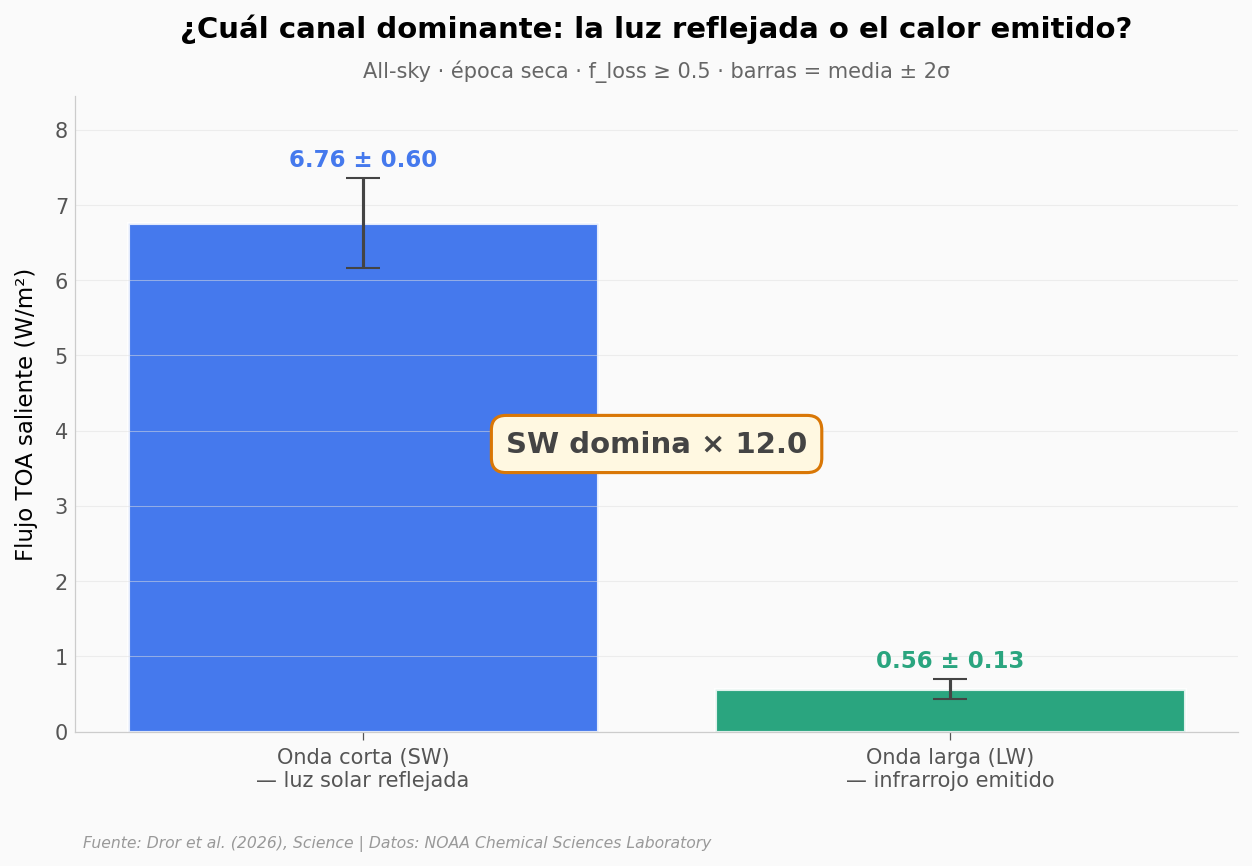


Dominancia espectral en alta deforestación:
  SW: 6.76 W/m²
  LW: 0.56 W/m²
  Ratio SW/LW: × 12.0


In [4]:
# All-sky, época seca, alta deforestación: SW vs LW
sub_all = summary[(summary['season']=='dry') & (summary['sky']=='all_sky')
                  & (summary['threshold']=='f_loss_geq_0.5')].copy()

quantities = ['Fsw', 'Flw']
q_labels = ['Onda corta (SW)\n— luz solar reflejada', 'Onda larga (LW)\n— infrarrojo emitido']
q_colors = [COLOR_DATOS, COLOR_LW]

fig, ax = plt.subplots(figsize=(10, 5.5))

means, errs = [], []
for q in quantities:
    row = sub_all[sub_all['quantity']==q].iloc[0]
    means.append(row['mean'])
    errs.append(row['standard_error_2sigma'])

bars = ax.bar(q_labels, means, yerr=errs, capsize=8,
              color=q_colors, alpha=0.85, edgecolor='white', linewidth=1.5,
              error_kw={'elinewidth': 1.5, 'ecolor': '#444444'})

for bar, val, err in zip(bars, means, errs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + err + 0.15,
            f'{val:.2f} ± {err:.2f}', ha='center', fontsize=11, fontweight='bold',
            color=bar.get_facecolor())

# Anotación de la dominancia
ratio = means[0] / means[1]
ax.annotate(f'SW domina × {ratio:.1f}',
            xy=(0.5, means[0] * 0.55), xytext=(0.5, means[0] * 0.55),
            fontsize=14, fontweight='bold', color='#444444', ha='center',
            bbox=dict(boxstyle='round,pad=0.5', fc='#FFF8E1', ec='#D97706', lw=1.5))

ax.set_ylabel('Flujo TOA saliente (W/m²)', fontsize=11)
ax.set_title('¿Cuál canal dominante: la luz reflejada o el calor emitido?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'All-sky · época seca · f_loss ≥ 0.5 · barras = media ± 2σ',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(top=means[0] * 1.25)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/sw_vs_lw.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nDominancia espectral en alta deforestación:")
print(f"  SW: {means[0]:.2f} W/m²")
print(f"  LW: {means[1]:.2f} W/m²")
print(f"  Ratio SW/LW: × {ratio:.1f}")


## ¿Qué tan grande es esto, comparado con los píxeles que apenas tocaron?

Los promedios pueden ocultar lo que pasa en los extremos. Veamos la distribución completa de los 122 bins, y dónde caen los dos números clave: la media de "alta deforestación" (6.76 W/m²) y el bin más extremo (f_loss = 0.85).


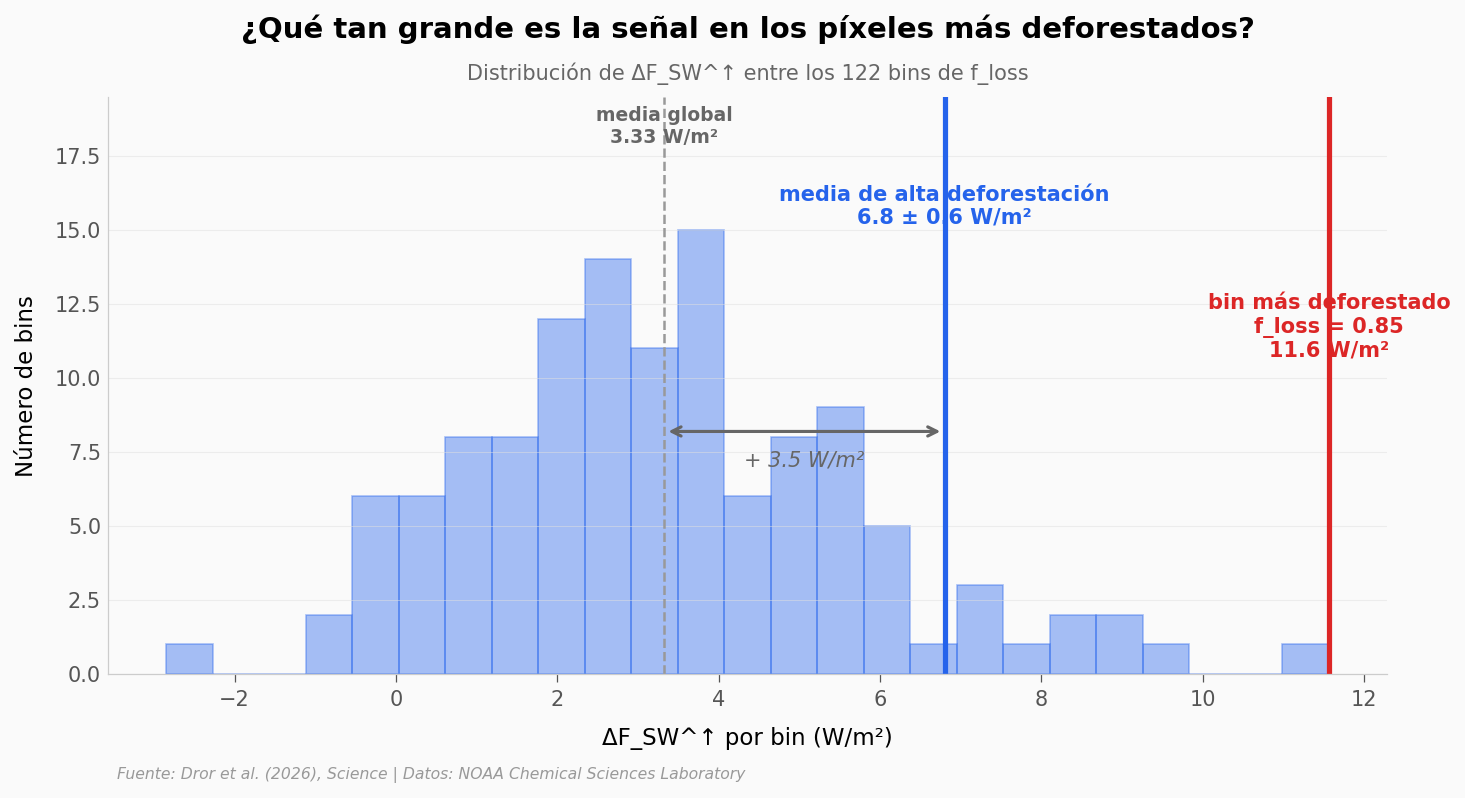

In [5]:
# Histograma de la distribución de ΔF_SW a lo largo de los 122 bins
fig, ax = plt.subplots(figsize=(11, 5))

n, bins_h, patches = ax.hist(df['dF_SW_Wm2'], bins=25, color=COLOR_DATOS, alpha=0.4,
                              edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.30
ax.set_ylim(0, y_max)

# Media global
mean_all = df['dF_SW_Wm2'].mean()
ax.axvline(x=mean_all, color='#999999', linewidth=1.2, linestyle='--')
ax.text(mean_all, y_max*0.92, f'media global\n{mean_all:.2f} W/m²',
        fontsize=9, color='#666666', ha='center', fontweight='bold')

# Headline: f_loss ≥ 0.5 (6.76 W/m²)
ax.axvline(x=HEADLINE_VALUE, color=COLOR_DATOS, linewidth=2.5)
ax.text(HEADLINE_VALUE, y_max*0.78,
        f'media de alta deforestación\n{HEADLINE_VALUE:.1f} ± {HEADLINE_2SE:.1f} W/m²',
        fontsize=10, color=COLOR_DATOS, ha='center', fontweight='bold')

# Bin más extremo
extreme = df['dF_SW_Wm2'].max()
extreme_floss = df.loc[df['dF_SW_Wm2'].idxmax(), 'f_loss']
ax.axvline(x=extreme, color=COLOR_ALERTA, linewidth=2.5)
ax.text(extreme, y_max*0.55, f'bin más deforestado\nf_loss = {extreme_floss:.2f}\n{extreme:.1f} W/m²',
        fontsize=10, color=COLOR_ALERTA, ha='center', fontweight='bold')

# Flecha bidireccional entre media global y headline
ax.annotate('', xy=(HEADLINE_VALUE, y_max*0.42), xytext=(mean_all, y_max*0.42),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((mean_all + HEADLINE_VALUE)/2, y_max*0.36,
        f'+ {HEADLINE_VALUE - mean_all:.1f} W/m²',
        fontsize=10, color='#666666', ha='center', style='italic')

ax.set_xlabel('ΔF_SW^↑ por bin (W/m²)', fontsize=11)
ax.set_ylabel('Número de bins', fontsize=11)
ax.set_title('¿Qué tan grande es la señal en los píxeles más deforestados?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución de ΔF_SW^↑ entre los 122 bins de f_loss',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histogram_anomaly.png', dpi=200, bbox_inches='tight')
plt.show()


### Lo que los datos sí dicen

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El techo de la atmósfera (TOA) en alta deforestación pierde 6.8 ± 0.6 W/m² extra (SW) | ✅ | Calculado: 6.76 ± 0.60 W/m² · coincide al 0.6% |
| Las nubes amplifican el efecto vs suelo desnudo (≈ doble) | ✅ | Amplificación de albedo × 2.2; del flujo SW × 3.4 |
| La onda corta domina sobre la onda larga | ✅ | SW/LW × 12 en alta deforestación |
| ΔF_SW escala con f_loss | ✅ | Pendiente OLS ~11 W/m² por unidad · R² = 0.61 · p ≈ 0 |

### Lo que los datos NO dicen

Esto es lo más importante de este paper, y la línea que el propio abstract dibuja con cuidado:

- **No es un balance climático completo.** Solo medimos el flujo radiativo en el techo de la atmósfera. No incluye carbono liberado al deforestar, ni cambios en la humedad atmosférica, ni el efecto sobre el ciclo hidrológico continental.
- **No es global.** Es la respuesta local sobre el Amazonas, en la época seca. El forzamiento climático del CO₂ liberado por esa misma deforestación opera a escala planetaria y a otros plazos.
- **El paper enmarca la implicación con cuidado.** El resumen dice que estos resultados *"apoyan"* (no *"demuestran"*) su integración en modelos climáticos y políticas de manejo. Estamos viendo una pieza de un rompecabezas, no la respuesta final.

> Decir "deforestar el Amazonas enfría el planeta" es saltar varios pasos. Lo que muestran los datos es: el techo de la atmósfera devuelve más luz solar al espacio cuando hay menos bosque en el dosel, y las nubes hacen ese efecto más fuerte de lo que el suelo pelado lo haría solo.


## Ahora tú

1. **¿Cuánto cambia el resultado si miras año completo en vez de época seca?** Pista: filtra `summary` con `season=='year'` en vez de `'dry'` y rehaz la comparación all-sky vs surface-only.
2. **¿Qué tan apretada es la relación si usas regresión robusta en vez de OLS?** Pista: `scipy.stats.theilslopes(df['dF_SW_Wm2'], df['f_loss'])` da la pendiente de Theil — menos sensible a outliers.
3. **¿La amplificación nubosa es la misma para LW que para SW?** Pista: repite la celda 7 cambiando `Fsw` por `Flw`. Los signos pueden ser distintos.


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿el efecto sobrevive en año completo?
sub_year = summary[(summary['season']=='year') & (summary['quantity']=='Fsw')
                   & (summary['threshold']=='f_loss_geq_0.5')]

all_year = sub_year[sub_year['sky']=='all_sky']['mean'].iloc[0]
surf_year = sub_year[sub_year['sky']=='surface_only']['mean'].iloc[0]
amp_year = all_year / surf_year

sub_dry = summary[(summary['season']=='dry') & (summary['quantity']=='Fsw')
                  & (summary['threshold']=='f_loss_geq_0.5')]
all_dry = sub_dry[sub_dry['sky']=='all_sky']['mean'].iloc[0]
surf_dry = sub_dry[sub_dry['sky']=='surface_only']['mean'].iloc[0]
amp_dry = all_dry / surf_dry

print("Comparación seco vs año completo (alta deforestación):")
print(f"  Época seca:    all-sky {all_dry:.2f} | surface {surf_dry:.2f} | amp × {amp_dry:.2f}")
print(f"  Año completo:  all-sky {all_year:.2f} | surface {surf_year:.2f} | amp × {amp_year:.2f}")
print(f"  Razón seco/año: × {all_dry/all_year:.2f}")


Comparación seco vs año completo (alta deforestación):
  Época seca:    all-sky 6.76 | surface 1.98 | amp × 3.41
  Año completo:  all-sky 6.17 | surface 2.42 | amp × 2.55
  Razón seco/año: × 1.09


---

## Fuentes

**Paper**: [Amazon forest loss: An all-sky biophysical top-of-atmosphere cooling feedback](https://doi.org/10.1126/science.adz8296)  
*Science, 2026-04-23*

**Datos**: [Supporting data for Dror & Feingold (Science 2026): Amazon forest loss TOA cooling feedback](https://csl.noaa.gov/groups/csl9/datasets/data/2026-Dror/)  
*NOAA Chemical Sciences Laboratory*

*17 afirmaciones verificadas contra estas fuentes*

**Paper:** Dror et al. (2026), *Amazon forest loss: An all-sky biophysical top-of-atmosphere cooling feedback*, **Science**. DOI: [10.1126/science.adz8296](https://doi.org/10.1126/science.adz8296)

**Repositorio del Lab:** [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · Licencia datos derivados: CC BY 4.0

*Notebook generado el 2026-04-27 · Ciencia a Mordiscos*
